In [2]:
#Data + Labels + Feature Table
%pip install earthengine-api
%pip install geemap
%pip install --upgrade certifi

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Authenticate and Initialize Earth Engine
import ee
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import os
from shapely.geometry import Point
ee.Authenticate(force=True)
ee.Initialize()


Successfully saved authorization token.


In [4]:
#Define Munich Region of Interest (ROI)
munich_roi = ee.Geometry.Rectangle([11.360, 48.061, 11.722, 48.248])        #Longitude and Latitude bounds for Munich

#Load Sentinel-2 Image Collection and Filter by Date and ROI
sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(munich_roi).filterDate('2023-01-01', '2023-12-31').filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))  #Filter for low cloud cover

#Median Composite to Reduce Noise
sentinel2_median = sentinel2.median().clip(munich_roi)  #Create a median composite and clip to ROI
sentinel2_10m = sentinel2_median.select(['B2', 'B3', 'B4', 'B8'])  #Resample to 10m resolution
print("Number of images:", sentinel2.size().getInfo()) #A total of 251 Sentinel-2 scenes were used to generate a cloud-reduced median composite for 2023
print(sentinel2_10m.bandNames().getInfo())

Number of images: 52
['B2', 'B3', 'B4', 'B8']


In [5]:
# Convert ROI to GeoJSON format explicitly
region_geojson = munich_roi.getInfo()['coordinates']
feature_image = sentinel2_10m.unmask(0).toFloat()  #Convert to float for better precision in exported data
task = ee.batch.Export.image.toDrive(
    image=feature_image,
    description='Munich_Sentinel2_Features_2023',
    folder='EarthEngineExports',
    fileNamePrefix='munich_s2_2023_features',
    region=region_geojson,
    scale=10,
    crs='EPSG:32632',
    maxPixels=1e13
)
task.start()

In [6]:
raster_path = "/Users/rajatdabral/downloads/Project/Maps/munich_s2_2023_features.tif"
src = rasterio.open(raster_path)
print("CRS:", src.crs)
print("Resolution:", src.res)
print("width:", src.width)
print("height:", src.height)
print("Number of bands:", src.count)

CRS: EPSG:32632
Resolution: (10.0, 10.0)
width: 2762
height: 2168
Number of bands: 4


In [7]:
#Load the raster data into a numpy array
raster_data = src.read()  #Read all bands into a 3D numpy array
bands, rows, cols = raster_data.shape
rows = int(rows)
cols = int(cols)
print("Raster data shape (bands, rows, cols):", raster_data.shape)

Raster data shape (bands, rows, cols): (4, 2168, 2762)


In [8]:
#Create Grid Dataframe
data_new = raster_data.reshape(bands, -1).T  #Reshape to (num_pixels, num_bands)
data_new = data_new[~np.isnan(data_new).any(axis=1)]  #Remove rows with NaN values
grid_df = pd.DataFrame(data_new, columns=['B2', 'B3', 'B4', 'B8'])  #Create DataFrame with band names as columns
print("Grid DataFrame shape:", grid_df.shape)
print(grid_df.head())

Grid DataFrame shape: (5605298, 4)
       B2      B3      B4      B8
0   760.0  1176.0   795.0  4188.0
1   788.0  1186.0   776.0  4264.0
2   730.0  1132.0   726.0  3604.0
3   624.0   792.0   715.0  2366.0
4  1026.0  1174.0  1136.0  2510.0


In [9]:
#Add Geospatial Coordinates to DataFrame

transform = src.transform

rows, cols = np.meshgrid(np.arange(src.height), np.arange(src.width), indexing='ij')
xs, ys = rasterio.transform.xy(transform, rows, cols)

xs = np.array(xs).flatten()
ys = np.array(ys).flatten()

# Same mask as before
mask = ~np.isnan(raster_data.reshape(bands, -1).T).any(axis=1)

coords = np.column_stack([xs, ys])[mask]

grid_df['x'] = coords[:, 0]
grid_df['y'] = coords[:, 1]

print("Grid DataFrame with coordinates shape:", grid_df.shape)
print(grid_df.head())

Grid DataFrame with coordinates shape: (5605298, 6)
       B2      B3      B4      B8         x          y
0   760.0  1176.0   795.0  4188.0  701865.0  5347445.0
1   788.0  1186.0   776.0  4264.0  701875.0  5347445.0
2   730.0  1132.0   726.0  3604.0  701885.0  5347445.0
3   624.0   792.0   715.0  2366.0  701895.0  5347445.0
4  1026.0  1174.0  1136.0  2510.0  701905.0  5347445.0


In [10]:
#Load the shapefiles download
landuse_shapefile_path = "/Users/rajatdabral/Downloads/Project/Maps/Bavaria.shp/gis_osm_landuse_a_free_1.shp"
landuse_gdf = gpd.read_file(landuse_shapefile_path)
print("Land Use GeoDataFrame shape:", landuse_gdf.shape)
print(landuse_gdf.head())

Land Use GeoDataFrame shape: (322756, 5)
    osm_id  code  fclass        name  \
0  3401793  7208  meadow  Adelberger   
1  3453426  7208  meadow        None   
2  3618206  7202    park        None   
3  3618801  7202    park        None   
4  3618802  7202    park        None   

                                            geometry  
0  POLYGON ((11.89869 48.19502, 11.90106 48.19573...  
1  POLYGON ((11.90188 48.19403, 11.90308 48.19416...  
2  POLYGON ((11.64588 48.12328, 11.64628 48.1238,...  
3  POLYGON ((11.65092 48.11876, 11.65116 48.11912...  
4  POLYGON ((11.6499 48.11955, 11.65008 48.1198, ...  


In [11]:
landuse_gdf['fclass'].unique()

array(['meadow', 'park', 'recreation_ground', 'cemetery', 'forest',
       'industrial', 'allotments', 'farmyard', 'residential', 'retail',
       'commercial', 'grass', 'farmland', 'scrub', 'quarry', 'military',
       'nature_reserve', 'heath', 'orchard', 'vineyard'], dtype=object)

In [12]:
#Create Label groups

def classify_landuse(fclass):

    if fclass in ['residential', 'industrial', 'commercial', 'retail', 'farmyard']:
        return 'built_up'

    elif fclass in ['forest', 'grass', 'meadow', 'farmland', 'scrub', 'nature_reserve', 'heath', 'orchard', 'vineyard', 'park', 'recreation_ground', 'allotments']:
        return 'vegetation'

    elif fclass in ['quarry']:
        return 'brownfield'

    else:
        return 'other'

landuse_gdf['landuse_label'] = landuse_gdf['fclass'].apply(classify_landuse)
landuse_gdf['landuse_label'].value_counts()

landuse_label
vegetation    280987
built_up       39331
other           1272
brownfield      1166
Name: count, dtype: int64

In [13]:
#landuse gdf crs conversion
landuse_gdf = landuse_gdf.to_crs(src.crs)
print("Land Use GeoDataFrame CRS:", landuse_gdf.crs)

Land Use GeoDataFrame CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]


In [14]:
#Spatial Join to Label Grid Points with Land Use Types
grid_gdf = gpd.GeoDataFrame(grid_df, geometry=gpd.points_from_xy(grid_df['x'], grid_df['y']), crs=src.crs)  #Create GeoDataFrame from grid DataFrame
print("Grid GeoDataFrame shape:", grid_gdf.shape)
print(grid_gdf.head())

Grid GeoDataFrame shape: (5605298, 7)
       B2      B3      B4      B8         x          y                geometry
0   760.0  1176.0   795.0  4188.0  701865.0  5347445.0  POINT (701865 5347445)
1   788.0  1186.0   776.0  4264.0  701875.0  5347445.0  POINT (701875 5347445)
2   730.0  1132.0   726.0  3604.0  701885.0  5347445.0  POINT (701885 5347445)
3   624.0   792.0   715.0  2366.0  701895.0  5347445.0  POINT (701895 5347445)
4  1026.0  1174.0  1136.0  2510.0  701905.0  5347445.0  POINT (701905 5347445)


In [15]:
#Join the grid points with land use polygons to assign land use labels to each point

joined_gdf = gpd.sjoin(grid_gdf, landuse_gdf[['geometry', 'landuse_label']], how='inner', predicate='intersects')  #Spatial join to assign land use labels

#Drop duplicate columns from the join
joined_gdf = joined_gdf.drop_duplicates(subset=['x', 'y'])  #Drop duplicate points based on coordinates

#Drop unnecessary columns from the join
joined_gdf = joined_gdf.drop(columns=['geometry', 'index_right'])  #Drop the geometry and index columns

print("Joined GeoDataFrame shape:", joined_gdf.shape)
print(joined_gdf.head())

Joined GeoDataFrame shape: (4838701, 7)
       B2      B3      B4      B8         x          y landuse_label
0   760.0  1176.0   795.0  4188.0  701865.0  5347445.0    vegetation
1   788.0  1186.0   776.0  4264.0  701875.0  5347445.0    vegetation
2   730.0  1132.0   726.0  3604.0  701885.0  5347445.0    vegetation
3   624.0   792.0   715.0  2366.0  701895.0  5347445.0      built_up
4  1026.0  1174.0  1136.0  2510.0  701905.0  5347445.0      built_up


In [16]:
joined_gdf["label"] = joined_gdf["landuse_label"].map({'built_up': 0, 'vegetation': 1, 'brownfield': 2, 'other': 3})  #Map land use labels to numeric values
print("Unique labels in joined GeoDataFrame:", joined_gdf["label"].unique())

Unique labels in joined GeoDataFrame: [1 0 3 2]


In [17]:
#Sample Data for Model Training
sampled_gdf = joined_gdf.sample(n=200000, random_state=42)
print("Sampled GeoDataFrame shape:", sampled_gdf.shape)
print(sampled_gdf.head())

Sampled GeoDataFrame shape: (200000, 8)
            B2     B3     B4      B8         x          y landuse_label  label
3859690  526.0  662.0  693.0  1660.0  697025.0  5332685.0      built_up      0
326690   290.0  568.0  648.0  2566.0  694095.0  5345795.0         other      3
3637130  367.0  454.0  375.0   986.0  683465.0  5333505.0    vegetation      1
4140685  751.0  794.0  893.0  1888.0  701065.0  5331645.0      built_up      0
5424708   73.0   94.0   97.0   956.0  692295.0  5326885.0    vegetation      1


In [18]:
#Prepare Training Data
X = sampled_gdf[['B2', 'B3', 'B4', 'B8']].values.astype("float32")  #Features
y_original = sampled_gdf['label'].values.astype("int64")  #Labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y_original.shape)

Feature matrix shape: (200000, 4)
Label vector shape: (200000,)


In [19]:
print(X.shape)
print(y_original.shape)
print(np.unique(y_original))

(200000, 4)
(200000,)
[0 1 2 3]


In [20]:
#Create Patches for CNN Input

# Patch size
PATCH_SIZE = 15
HALF = PATCH_SIZE // 2

# Pad raster
padded = np.pad(raster_data, ((0,0), (HALF, HALF), (HALF, HALF)), mode='reflect')

X_patches = []
y_labels = []

for _, row in sampled_gdf.iterrows():

    col = int((row['x'] - src.transform[2]) / src.transform[0])
    row_idx = int((row['y'] - src.transform[5]) / src.transform[4])

    row_idx += HALF
    col += HALF

    patch = padded[:, row_idx-HALF:row_idx+HALF+1,
                         col-HALF:col+HALF+1]

    if patch.shape == (4, PATCH_SIZE, PATCH_SIZE):
        X_patches.append(patch)
        y_labels.append(row['label'])

X = np.array(X_patches, dtype=np.float32)
y = np.array(y_labels, dtype=np.int64)

X = X = (X - X.mean()) / (X.std() + 1e-8)

print(X.shape, y.shape, np.unique(y))

(200000, 4, 15, 15) (200000,) [0 1 2 3]


In [21]:
#Class Weights for Imbalance

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_counts = np.bincount(y, minlength=4)
print("Class counts:", class_counts)

weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum()

weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

Class counts: [ 85234 109937    849   3980]


In [22]:
#Create PyTorch Dataset

from torch.utils.data import Dataset

class LandUseDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
dataset = LandUseDataset(X, y)

In [23]:
#Dataloader

from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size = 64, shuffle = True)

In [24]:
#Model

import torch.nn as nn
import torch.nn.functional as F

class LandUseCNN(nn.Module):
    def __init__(self):
        super(LandUseCNN, self).__init__()

        self.conv1 = nn.Conv2d(4, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 4)


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [25]:
#Setup Training

model = LandUseCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
#Training

for epoch in range(5):
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()

In [27]:
#Save the trained model for future inference

torch.save(model.state_dict(), "landuse_model.pth")

In [28]:
#Generate Predictions on the Entire Grid

In [29]:
#Load Model

model = LandUseCNN().to(device)
model.load_state_dict(torch.load("landuse_model.pth"))
model.eval()

LandUseCNN(
  (conv1): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)

In [30]:
#Run Prediction

rows = src.height
cols = src.width

all_preds = []

with torch.no_grad():
    for i in range(HALF, rows - HALF):
        for j in range(HALF, cols - HALF):

            patch = raster_data[:, i-HALF:i+HALF+1, j-HALF:j+HALF+1]

            if np.isnan(patch).any():
                all_preds.append(np.nan)
                continue

            patch = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).to(device)

            output = model(patch)
            pred = torch.argmax(output, dim=1).item()

            all_preds.append(pred)

In [31]:
_, H, W = raster_data.shape

In [32]:
#Convert back to Raster

import numpy as np

flat_preds = np.array(all_preds)

mask = ~np.isnan(raster_data.reshape(bands, -1).T).any(axis=1)

valid_indices = np.where(mask)[0]
flat_preds = flat_preds[:len(valid_indices)]

# use correct dimensions
_, H, W = raster_data.shape

prediction_map = np.full((H * W,), np.nan)

prediction_map[valid_indices] = flat_preds

prediction_map = prediction_map.reshape(H, W)

In [43]:
# Ground-truth imports

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

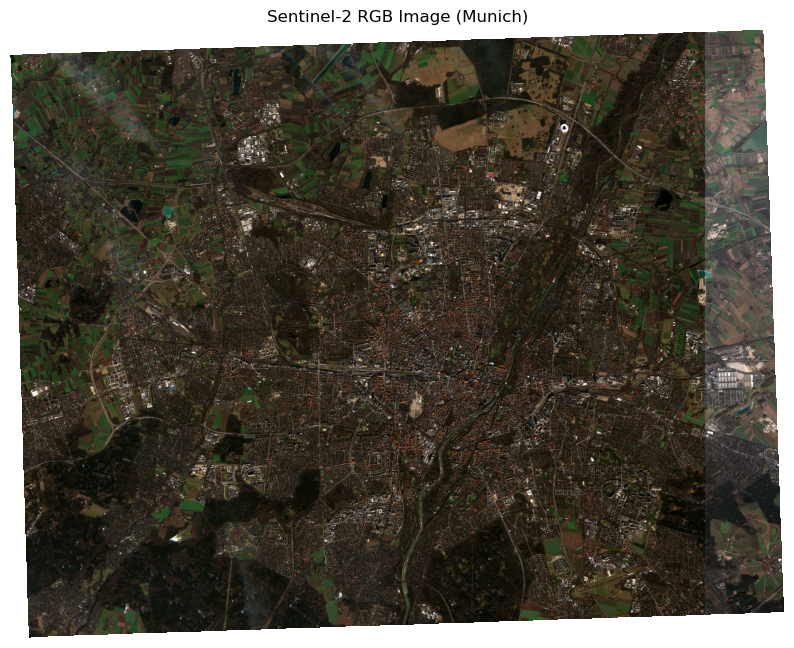

In [44]:
#Figure 1 : Satellite Image (TIF)

rgb = np.stack([
    raster_data[2],  # B4
    raster_data[1],  # B3
    raster_data[0]   # B2
], axis=-1).astype(float)

# divide by 10000 (Sentinel standard scaling)
rgb = rgb / 10000.0

# clip values
rgb = np.clip(rgb, 0, 0.3)   # important for contrast

# stretch to 0–1
rgb = rgb / 0.3

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.title("Sentinel-2 RGB Image (Munich)")
plt.axis('off')
plt.show()

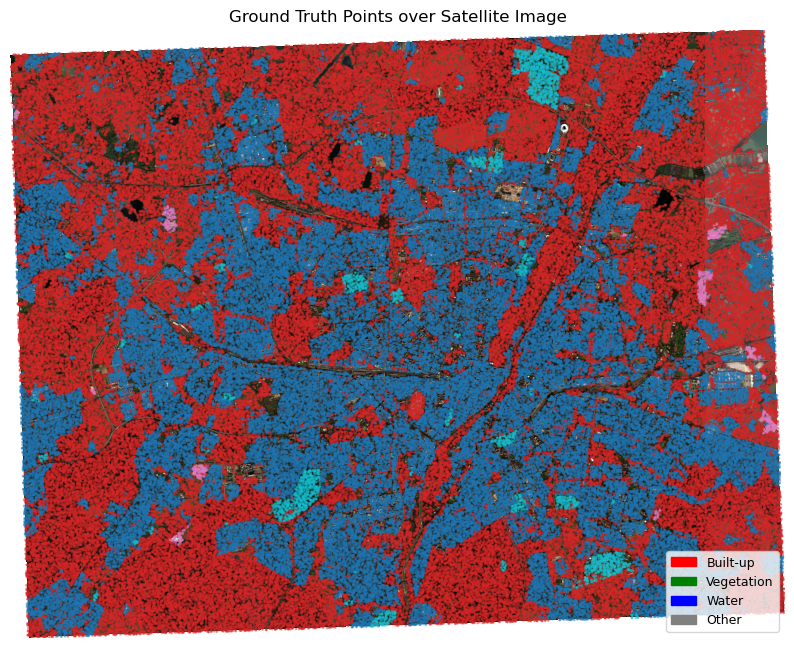

In [49]:
#Figure 2: Ground-truth Points

import matplotlib.patches as mpatches

# Convert ALL points to pixel coordinates (vectorized)
cols = ((sampled_gdf['x'] - src.transform[2]) / src.transform[0]).astype(int).values
rows = ((sampled_gdf['y'] - src.transform[5]) / src.transform[4]).astype(int).values

labels = sampled_gdf['label'].values

# Remove points outside raster bounds (important)
valid = (rows >= 0) & (rows < rgb.shape[0]) & (cols >= 0) & (cols < rgb.shape[1])

rows = rows[valid]
cols = cols[valid]
labels = labels[valid]

# Plot
plt.figure(figsize=(10,10))

# Background image
plt.imshow(rgb)

# Plot points
scatter = plt.scatter(
    cols,
    rows,
    c=labels,
    cmap='tab10',
    s=1,          
    alpha=0.4
)

legend_patches = [
    mpatches.Patch(color='red', label='Built-up'),
    mpatches.Patch(color='green', label='Vegetation'),
    mpatches.Patch(color='blue', label='Water'),
    mpatches.Patch(color='gray', label='Other')
]

plt.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.title("Ground Truth Points over Satellite Image", fontsize=12)
plt.axis('off')

plt.show()

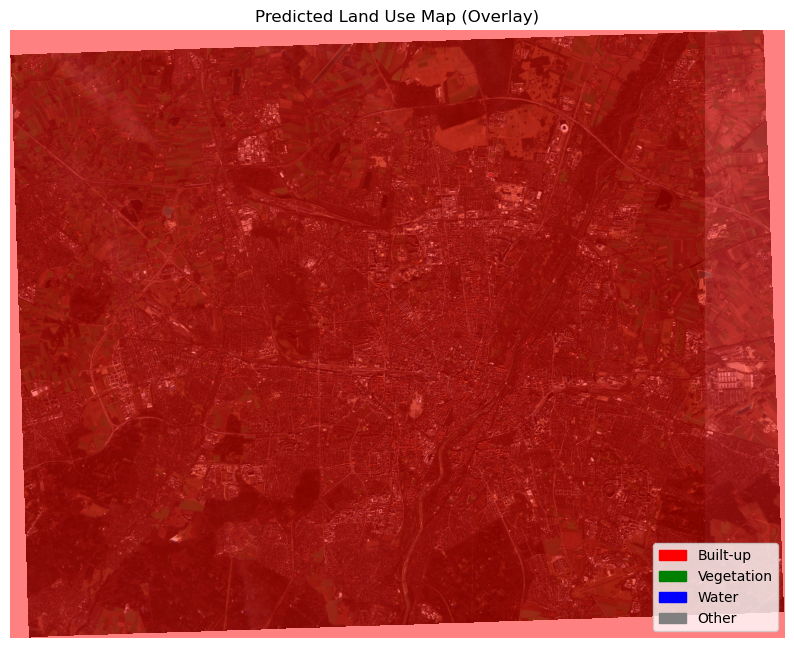

In [52]:
#Figure 3: Prediction Map

plt.figure(figsize=(10,10))

# Show satellite image
plt.imshow(rgb)

# Overlay prediction
plt.imshow(prediction_map, cmap=cmap, norm=norm, alpha=0.5)

# Legend
import matplotlib.patches as mpatches

legend_patches = [
    mpatches.Patch(color='red', label='Built-up'),
    mpatches.Patch(color='green', label='Vegetation'),
    mpatches.Patch(color='blue', label='Water'),
    mpatches.Patch(color='gray', label='Other')
]

plt.legend(handles=legend_patches, loc='lower right')

plt.title("Predicted Land Use Map (Overlay)", fontsize=12)
plt.axis('off')

plt.show()